In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
data = pd.read_csv('./Air_Pollution_Prediction_Final/data/Train_data.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)
data.sort_values(by='from_date', inplace=True)
data.head()

,from_date,to_date,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,Date,time_idx,city
0,2017-01-01 00:00:00,2017-01-01 01:00:00,212.535000,326.436250,54.380909,82.325000,51.679091,99.992000,16.894,2.032500,20.7800,791.506,0.565000,12.128,85.467143,0.0,2017-01-01,1,Delhi
22,2017-01-01 01:00:00,2017-01-01 02:00:00,221.626667,349.794286,57.869000,81.743333,50.840000,104.844444,15.530,2.308571,20.2050,791.420,0.595000,11.600,86.110000,0.0,2017-01-01,2,Delhi
21,2017-01-01 02:00:00,2017-01-01 03:00:00,217.650000,336.096250,42.166364,71.381667,43.699091,78.736000,13.922,1.623750,46.0625,791.380,0.498333,11.336,86.748571,0.0,2017-01-01,3,Delhi
20,2017-01-01 03:00:00,2017-01-01 04:00:00,226.055000,307.732500,41.658182,70.268333,38.291818,72.843000,13.780,1.568571,27.9700,791.540,0.531667,10.564,86.732857,0.0,2017-01-01,4,Delhi
19,2017-01-01 04:00:00,2017-01-01 05:00:00,219.325556,277.064286,56.181000,61.455000,34.336000,92.034444,15.322,1.868333,16.5950,791.634,0.386667,9.900,87.377143,0.0,2017-01-01,5,Delhi


In [19]:
data.columns

Index(['from_date', 'to_date', 'pm25', 'pm10', 'no', 'nh3', 'no2', 'nox',
       'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity',
       'rainfall', 'Date', 'time_idx', 'city'],
      dtype='object')

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52584 entries, 0 to 52571
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   from_date   52584 non-null  object 
 1   to_date     52584 non-null  object 
 2   pm25        52584 non-null  float64
 3   pm10        52584 non-null  float64
 4   no          52584 non-null  float64
 5   nh3         52584 non-null  float64
 6   no2         52584 non-null  float64
 7   nox         52584 non-null  float64
 8   so2         52584 non-null  float64
 9   co          52584 non-null  float64
 10  ozone       52584 non-null  float64
 11  bp          52584 non-null  float64
 12  wind_speed  52584 non-null  float64
 13  air_temp    52584 non-null  float64
 14  humidity    52584 non-null  float64
 15  rainfall    52584 non-null  float64
 16  Date        52584 non-null  object 
 17  time_idx    52584 non-null  int64  
 18  city        52584 non-null  object 
dtypes: float64(14), int64(1), obje

In [21]:
data.isna().sum()

from_date     0
to_date       0
pm25          0
pm10          0
no            0
nh3           0
no2           0
nox           0
so2           0
co            0
ozone         0
bp            0
wind_speed    0
air_temp      0
humidity      0
rainfall      0
Date          0
time_idx      0
city          0
dtype: int64

In [22]:
data.describe()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
count,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000,52584.000000
mean,105.807970,214.941618,34.820944,40.445992,42.875634,56.414892,13.747347,1.340386,33.167971,935.136006,1.114359,25.431936,59.207689,0.019927,26292.500000
std,88.738415,135.907634,41.896787,13.961314,20.923523,45.572824,6.317732,0.778844,25.401158,52.007068,0.613389,8.158729,20.411011,0.245100,15179.837614
min,3.043333,8.200000,2.971143,4.370000,10.221143,8.302727,0.010000,0.000000,1.985000,733.063333,0.134286,4.267500,3.037500,0.000000,1.000000
25%,43.279857,109.789915,10.845000,30.932976,26.499424,26.348152,9.477662,0.860409,14.474706,937.827336,0.673300,19.211976,43.403148,0.000000,13146.750000
50%,76.161182,187.173896,17.330409,38.392546,38.051264,39.607468,12.055714,1.090923,23.097438,955.328958,0.986000,26.850714,61.040577,0.000000,26292.500000
75%,142.089214,293.185384,37.984449,47.684135,54.913500,68.519228,16.206810,1.534000,44.945417,965.389130,1.428148,31.375000,76.476250,0.000000,39438.250000
max,847.942381,1000.000000,323.415000,254.700000,188.248919,368.870000,81.886429,12.632500,159.140000,1013.880000,26.455000,47.573333,97.352000,30.500000,52584.000000


In [23]:
## Outliers present for: [pm25, pm10, no, nh3, no2, nox, so2, co, ozone, wind speed, rainfall, pm25_lag1, pm25_lag7]
## Maybe: [bp, air temp]

In [24]:
data.columns

Index(['from_date', 'to_date', 'pm25', 'pm10', 'no', 'nh3', 'no2', 'nox',
       'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity',
       'rainfall', 'Date', 'time_idx', 'city'],
      dtype='object')

pm25


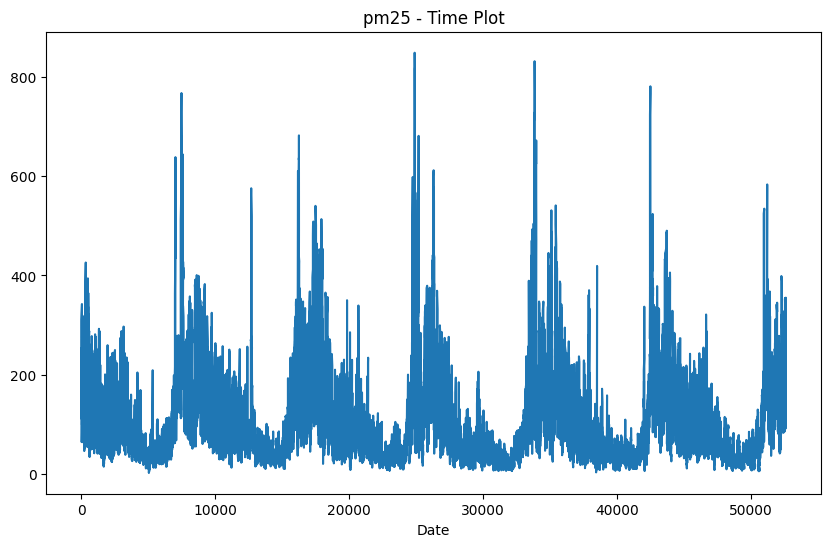

pm10


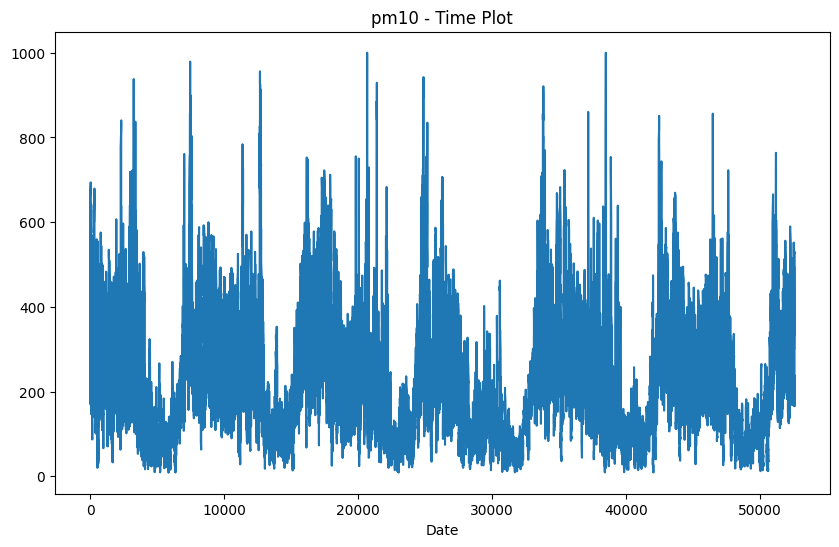

no


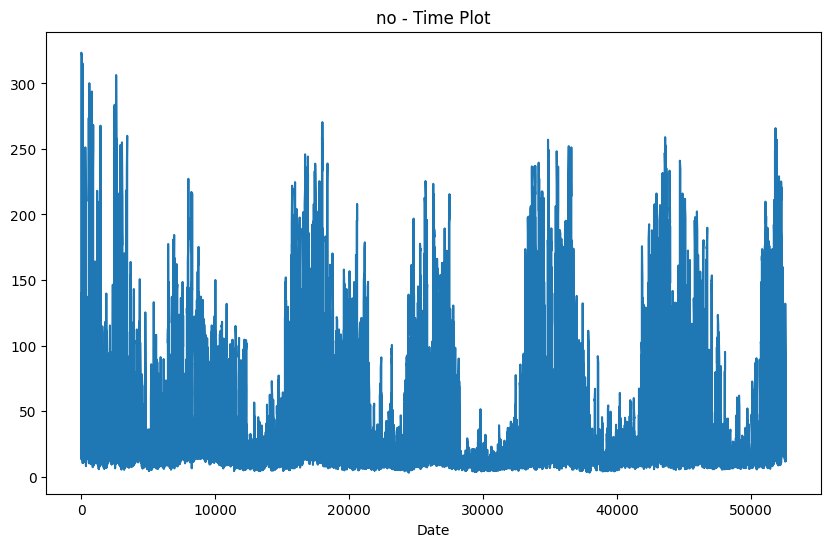

nh3


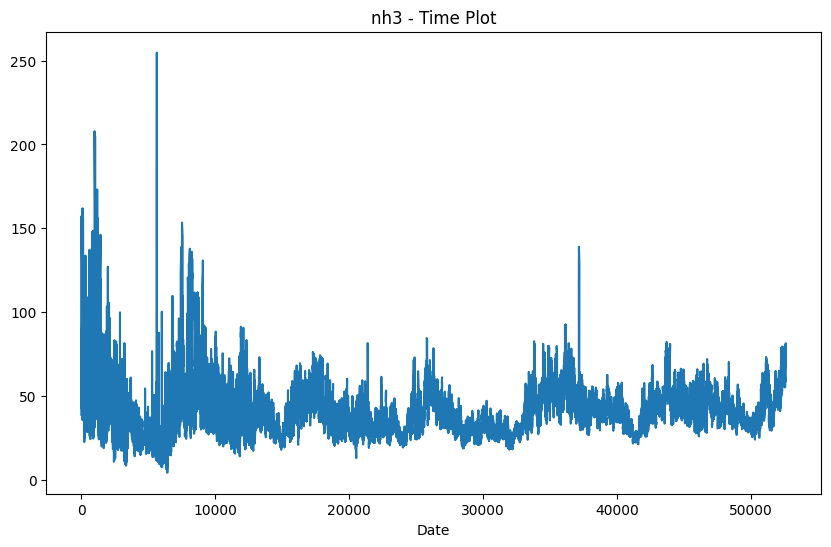

no2


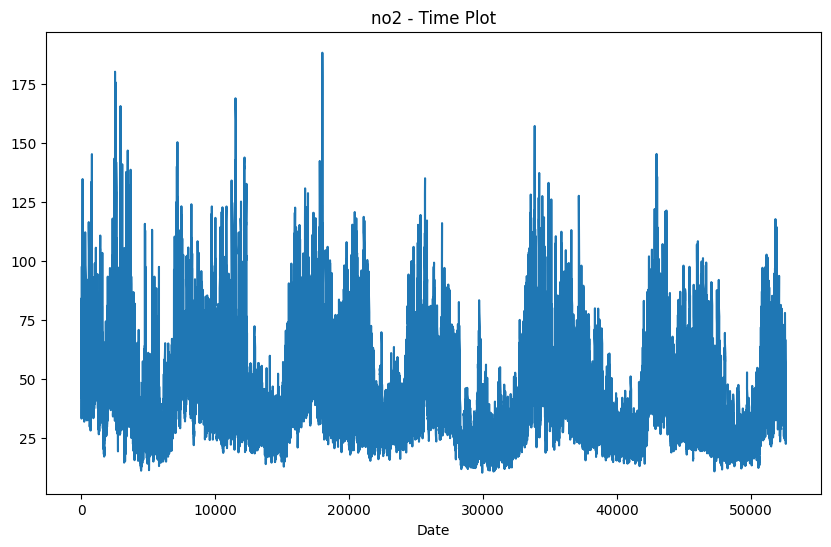

nox


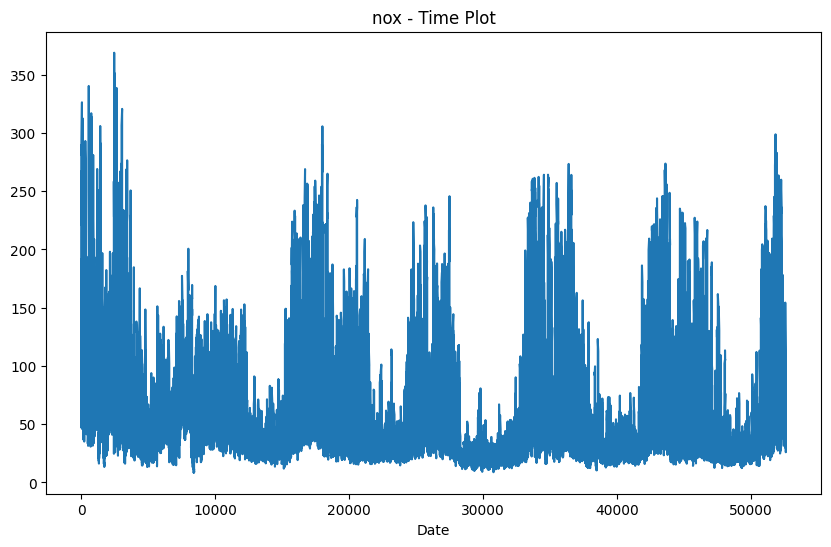

so2


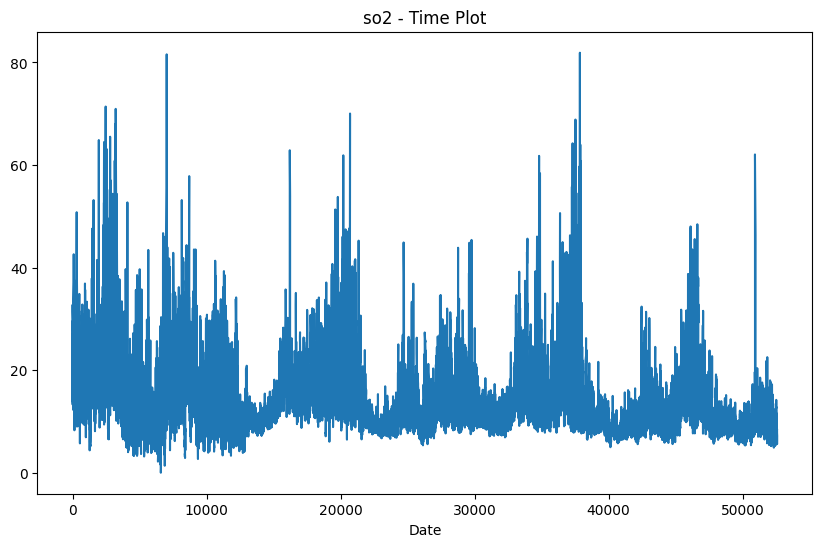

co


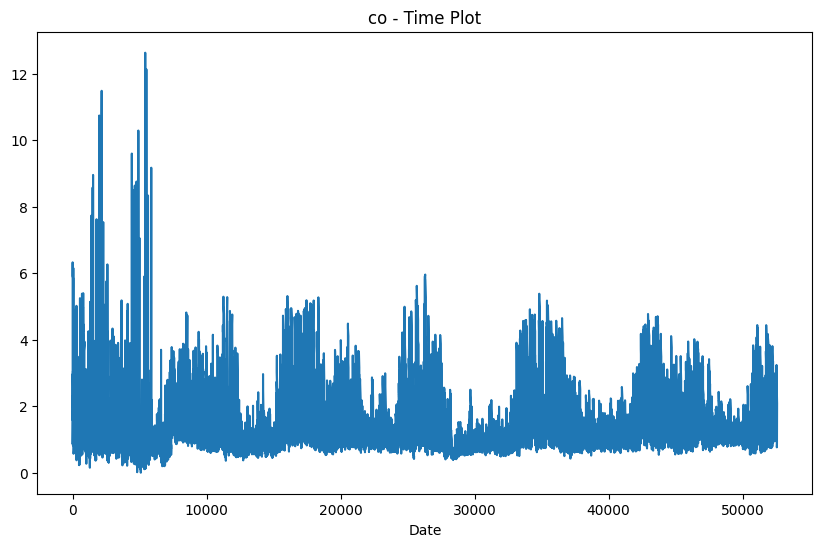

ozone


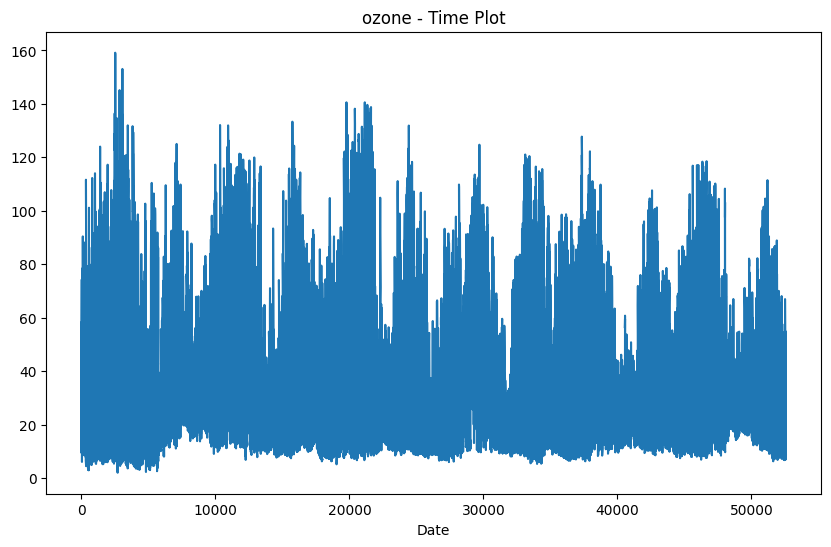

bp


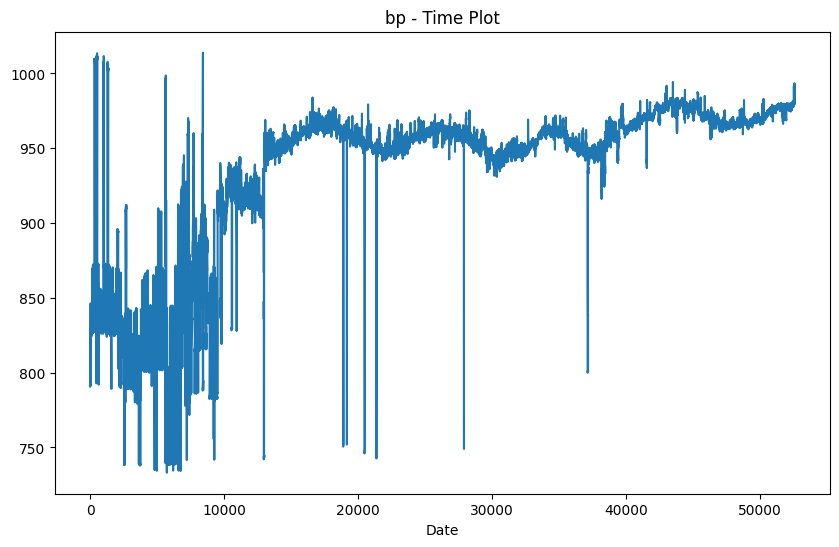

wind_speed


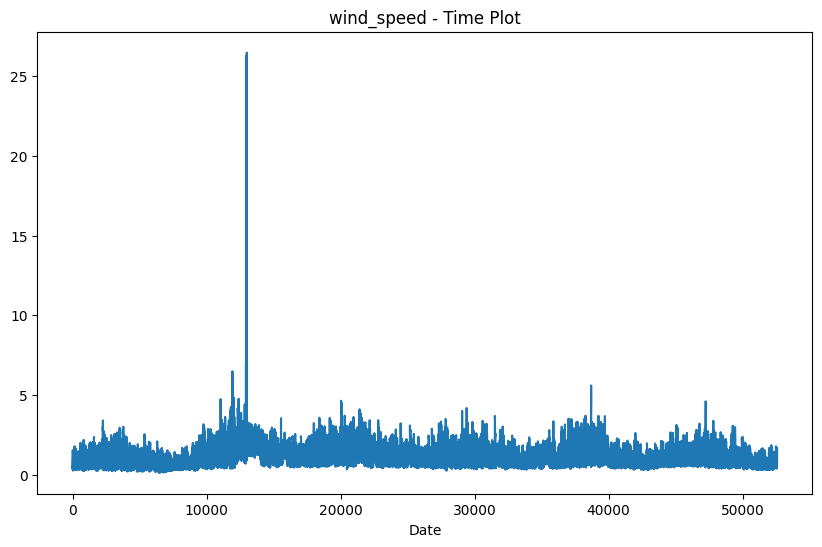

air_temp


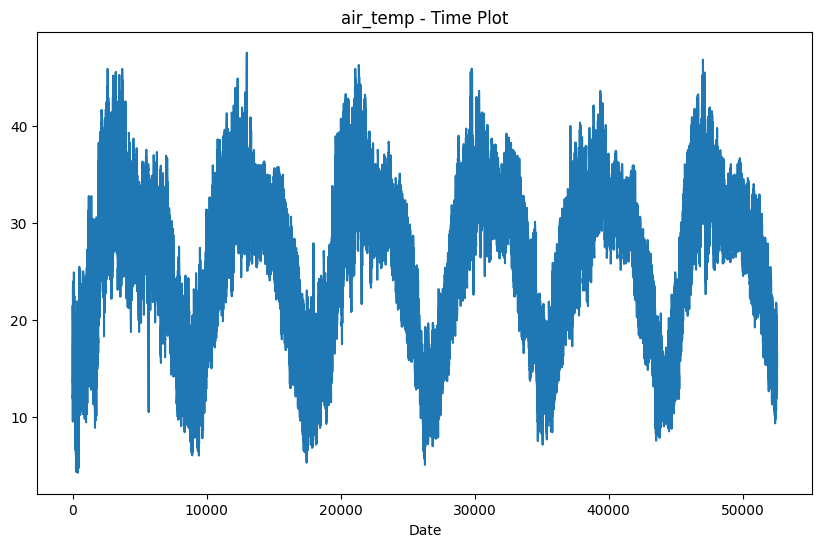

humidity


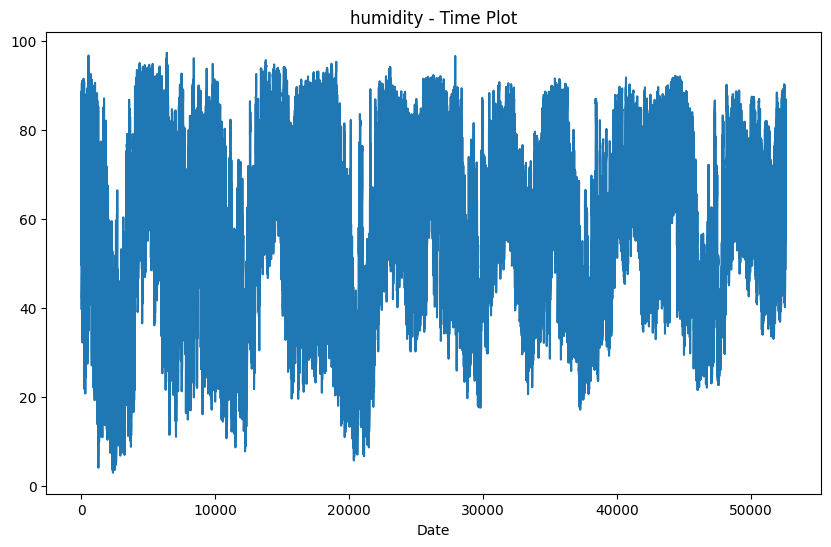

rainfall


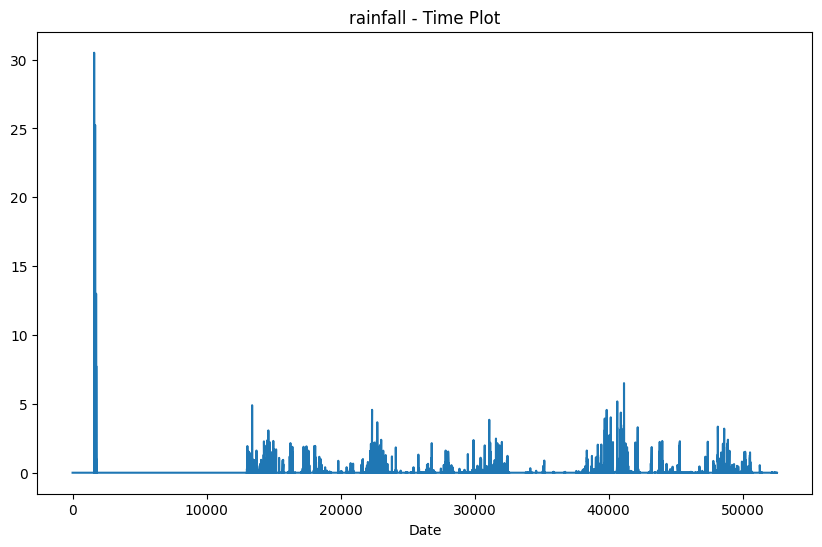

In [33]:
# Plot
for i in ['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox',
       'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity',
       'rainfall']:
    print(i)
    data[i].plot(title='{0} - Time Plot'.format(i), figsize=(10,6)) 
    plt.xlabel('Date')
    plt.show()

In [34]:
## Visible repetative patterns:

## Strong seasonal: pm25, pm10, no2, ait temo, humidity, pm25lag1, pm25lag7
## Week but seasonal: no, nh3, nox, so2, co 
## Uncertain seasonal: ozone, wind speed
## No seasonal: bp, rainfall

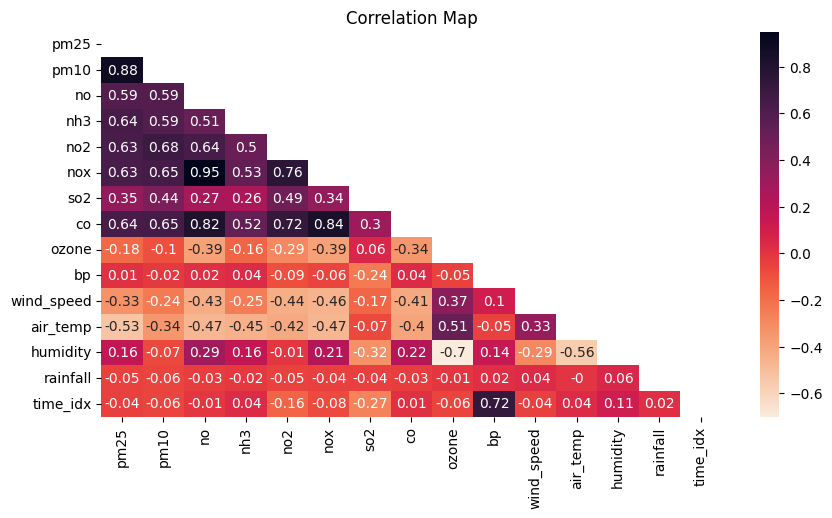

In [35]:
import seaborn as sns

corr = data.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,5))
sns.heatmap(data=corr, mask=mask, annot=True, cmap="rocket_r")
plt.title('Correlation Map')
plt.show()

In [36]:
## pm25 - pm 10
## no - nox
## no2 - nox
## co - no
## co - nox
## ozone : barely but inverse
## bp : independent
## wind speed : barely but inverse
## air temp: barely but inverse
## humiditty : independent
## rainfall : independent 

In [37]:
## Posible set of gasses for prediction: [pm25, no2, co, ozone] / [pm10, no2, co, ozone]

In [38]:
from statsmodels.graphics.tsaplots import plot_acf

pm25


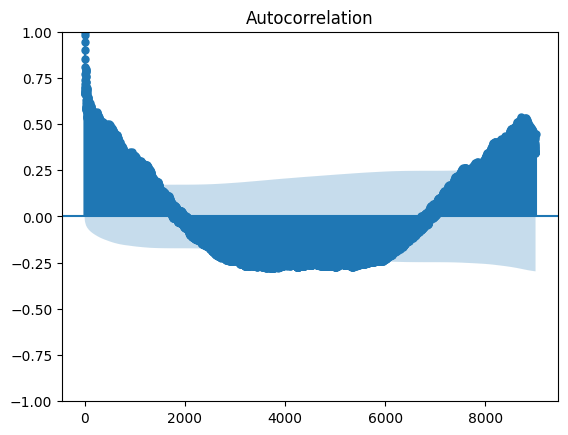

pm10


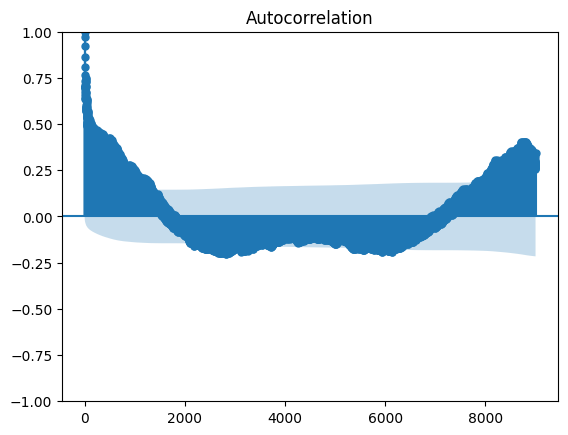

no


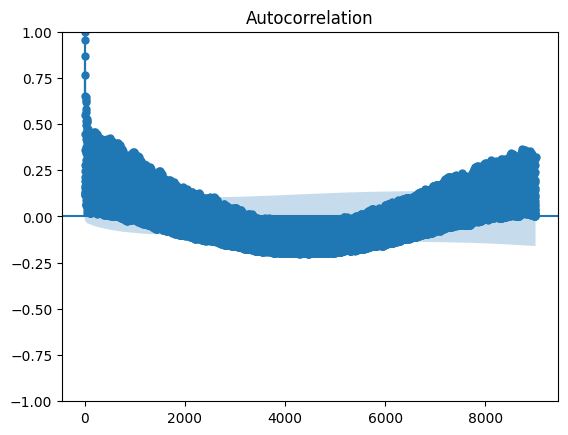

nh3


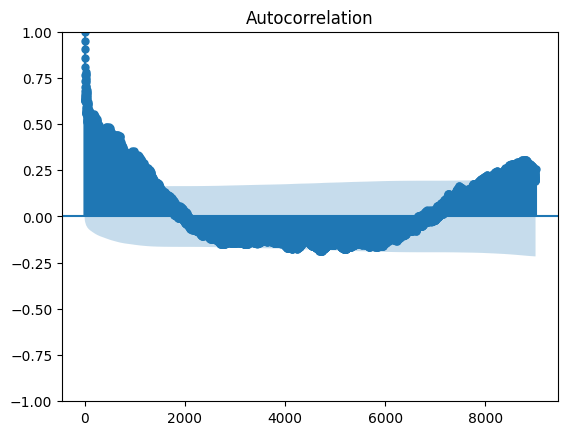

no2


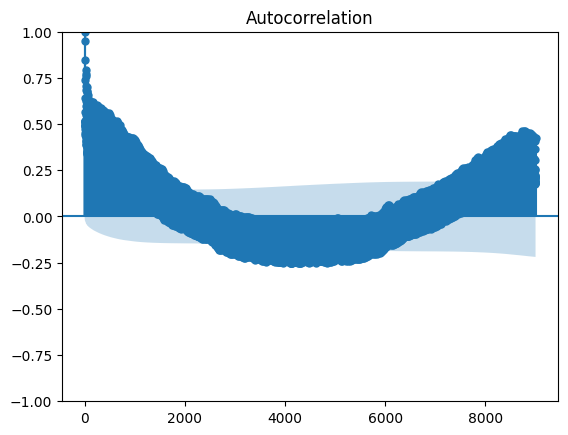

nox


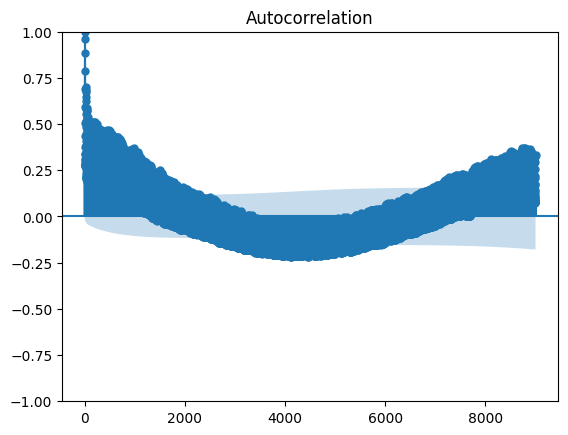

so2


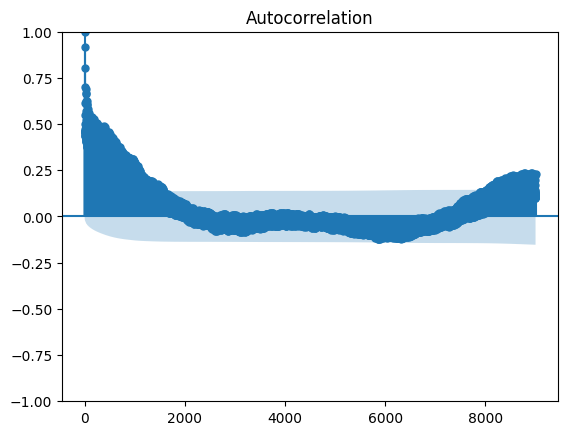

co


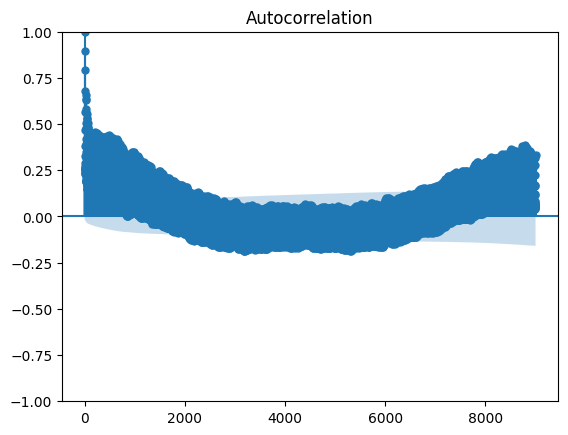

ozone


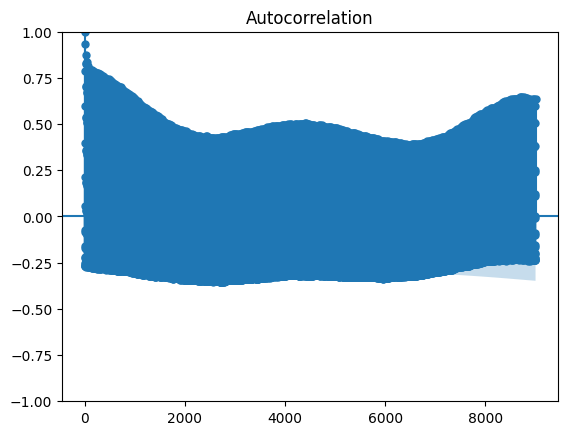

bp


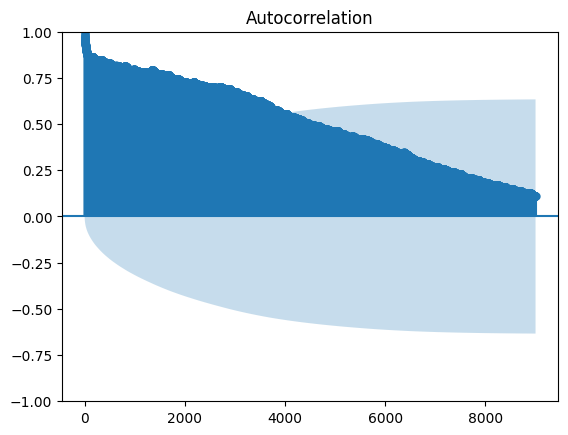

wind_speed


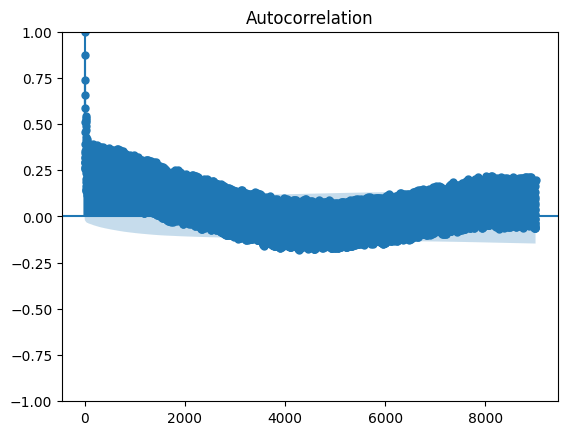

air_temp


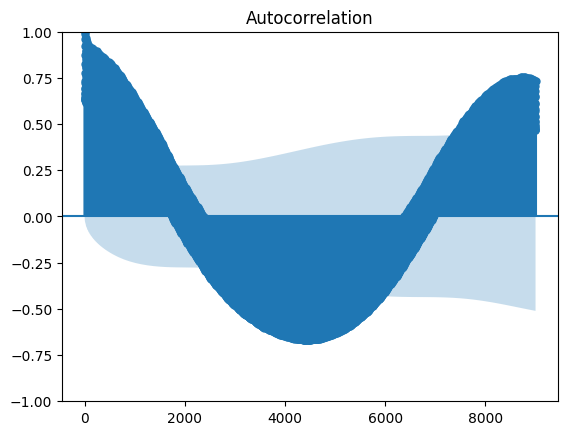

humidity


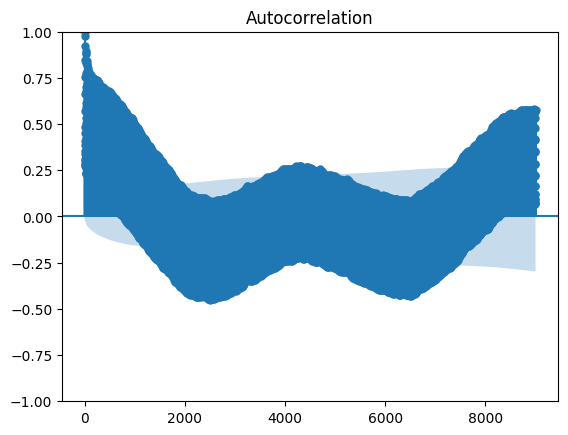

rainfall


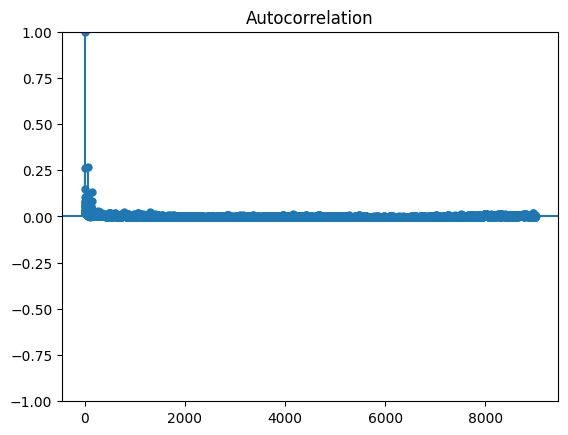

In [39]:
for i in ['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox',
       'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity',
       'rainfall']:
    print(i)
    plot_acf(data[i], lags=9000)
    plt.show()